In [ ]:
#impqrt necessary libraries
import os
import json
import random
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageFile

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


In [ ]:
# To handle truncated images
ImageFile.LOAD_TRUNCATED_IMAGES = True

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


Device: cuda


In [ ]:
# Load class map
with open("class_map.json", "r") as f:
    class_map = json.load(f)

print("Class map:", class_map)
id_to_class = {v: k for k, v in class_map.items()}
num_classes = len(class_map)
print("ID to class:", id_to_class)

Class map: {'basophil': 0, 'eosinophil': 1, 'erythroblast': 2, 'ig': 3, 'lymphocyte': 4, 'monocyte': 5, 'neutrophil': 6, 'platelet': 7}
ID to class: {0: 'basophil', 1: 'eosinophil', 2: 'erythroblast', 3: 'ig', 4: 'lymphocyte', 5: 'monocyte', 6: 'neutrophil', 7: 'platelet'}


In [ ]:
# Build samples from training directory
def build_samples(root_dir, class_map):
    """Collect (image_path, label_id) pairs from the training directory."""
    samples = []
    for class_name, label in class_map.items():
        class_dir = os.path.join(root_dir, class_name)
        if not os.path.isdir(class_dir):
            print("Warning: missing folder for class:", class_name)
            continue
        for fname in os.listdir(class_dir):
            if fname.lower().endswith((".jpg", ".jpeg", ".png")):
                full_path = os.path.join(class_dir, fname)
                samples.append((full_path, label))
    return samples

all_samples = build_samples("train", class_map)
print("Total training images:", len(all_samples))

all_paths, all_labels = zip(*all_samples)
all_paths, all_labels = list(all_paths), list(all_labels)

print("Example sample:", all_paths[0], "label:", all_labels[0])



Total training images: 3200
Example sample: train\basophil\BA_101381.jpg label: 0


Raw label counts: Counter({0: 400, 1: 400, 2: 400, 3: 400, 4: 400, 5: 400, 6: 400, 7: 400})


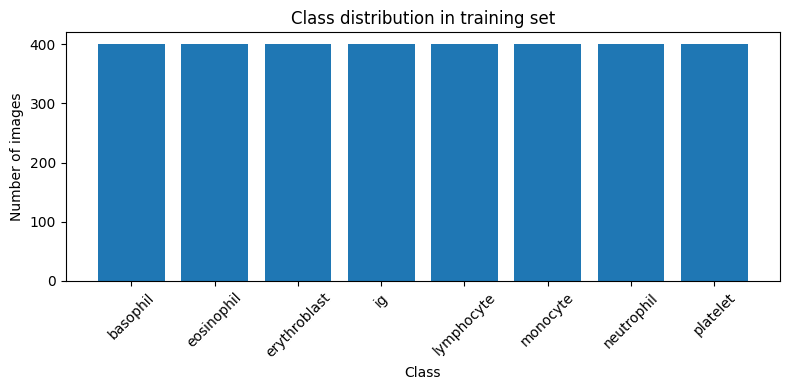

In [ ]:
# Visualize class distribution
label_counts = Counter(all_labels)
print("Raw label counts:", label_counts)

class_names = [id_to_class[i] for i in range(num_classes)]
counts = [label_counts[i] for i in range(num_classes)]

plt.figure(figsize=(8, 4))
plt.bar(class_names, counts)
plt.title("Class distribution in training set")
plt.xlabel("Class")
plt.ylabel("Number of images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

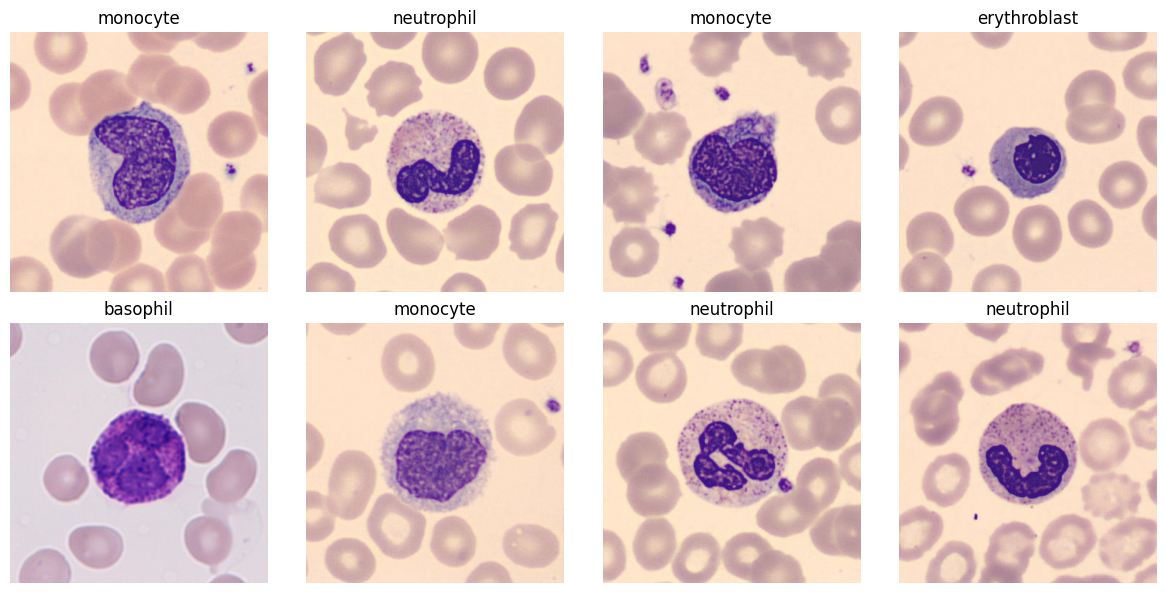

In [ ]:
# Visualise sample images
def show_sample_images(paths, labels, n=8):
    """Visualise random sample images from the dataset."""
    plt.figure(figsize=(12, 6))
    indices = np.random.choice(len(paths), size=min(n, len(paths)), replace=False)
    for i, idx in enumerate(indices):
        img_path = paths[idx]
        label = labels[idx]
        img = Image.open(img_path).convert("RGB")
        plt.subplot(2, 4, i + 1)
        plt.imshow(img)
        plt.title(id_to_class[label])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_sample_images(all_paths, all_labels, n=8)

In [ ]:
# Stratified train-val split
train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_paths,
    all_labels,
    test_size=0.2,
    random_state=42,
    stratify=all_labels,
)

print("Train size:", len(train_paths))
print("Val size:", len(val_paths))
print("Train class distribution:", Counter(train_labels))
print("Val class distribution:", Counter(val_labels))

Train size: 2560
Val size: 640
Train class distribution: Counter({4: 320, 3: 320, 5: 320, 2: 320, 6: 320, 0: 320, 7: 320, 1: 320})
Val class distribution: Counter({6: 80, 4: 80, 5: 80, 1: 80, 0: 80, 2: 80, 3: 80, 7: 80})


In [ ]:
# Data augmentations and transformations
# Aggressive augmentations for training
train_tf = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.25, hue=0.05),
    transforms.ToTensor(),
])

# Simple resize for validation and test
val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])
test_tf = val_tf

In [11]:
# Simple resize for validation and test
val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])
test_tf = val_tf


class CellTrainValDataset(Dataset):
    """Dataset for labeled train/validation images."""
    def __init__(self, paths, labels, transform=None):
        self.paths = list(paths)
        self.labels = list(labels)
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        label = self.labels[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label


class CellTestDataset(Dataset):
    """Dataset for unlabeled test images."""
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.paths = [
            os.path.join(root_dir, f)
            for f in os.listdir(root_dir)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ]
        self.paths.sort()  # deterministic order

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        filename = os.path.basename(path)
        return img, filename


In [ ]:
# Data loaders with weighted random sampler for training
train_class_counts = Counter(train_labels)
print("Train class counts:", train_class_counts)
weights = [1.0 / train_class_counts[lab] for lab in train_labels]
sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

batch_size = 32

train_dataset = CellTrainValDataset(train_paths, train_labels, transform=train_tf)
val_dataset   = CellTrainValDataset(val_paths,   val_labels,   transform=val_tf)
test_dataset  = CellTestDataset("test", transform=test_tf)

train_loader = DataLoader(train_dataset, batch_size=batch_size,
                          sampler=sampler, num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size,
                          shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size,
                          shuffle=False, num_workers=0)

print("Batches:", len(train_loader), len(val_loader), len(test_loader))

Train class counts: Counter({4: 320, 3: 320, 5: 320, 2: 320, 6: 320, 0: 320, 7: 320, 1: 320})
Batches: 80 20 32


In [ ]:
# Define models
class MLPBaseline(nn.Module):
    """Baseline 1: Simple MLP on flattened image pixels."""
    def __init__(self, num_classes=8):
        super().__init__()
        self.flatten = nn.Flatten()
        input_dim = 3 * 224 * 224
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.flatten(x)
        x = self.net(x)
        return x


class SmallCNN(nn.Module):
    """Baseline 2: Small CNN with two conv layers."""
    def __init__(self, num_classes=8):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 112x112

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 56x56
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 56 * 56, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


class Mish(nn.Module):
    """Custom Mish activation: x * tanh(softplus(x))."""
    def forward(self, x):
        return x * torch.tanh(F.softplus(x))


class SEBlock(nn.Module):
    """Squeeze-and-Excitation block for channel-wise attention."""
    def __init__(self, in_ch, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(in_ch, in_ch // reduction),
            nn.ReLU(),
            nn.Linear(in_ch // reduction, in_ch),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y


class ResidualBlock(nn.Module):
    """ResNet-style residual block with SE attention."""
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            Mish(),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
        )
        self.se = SEBlock(out_ch)

        if in_ch != out_ch or stride != 1:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )
        else:
            self.shortcut = nn.Identity()

        self.act = Mish()

    def forward(self, x):
        out = self.conv(x)
        out = self.se(out)
        out = out + self.shortcut(x)
        return self.act(out)


class DeepResCNN(nn.Module):
    """Main model: deeper residual CNN with SE blocks (from scratch)."""
    def __init__(self, num_classes=8):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(32),
            Mish(),
        )

        self.layers = nn.Sequential(
            ResidualBlock(32, 64, stride=2),
            ResidualBlock(64, 64),
            ResidualBlock(64, 128, stride=2),
            ResidualBlock(128, 128),
            ResidualBlock(128, 256, stride=2),
            ResidualBlock(256, 256),
            ResidualBlock(256, 512, stride=2),
            ResidualBlock(512, 512),
        )

        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.layers(x)
        x = self.head(x)
        return x

In [ ]:
# Training and evaluation functions
def train_one_epoch(model, loader, criterion, optimizer, device):
    """Train the model for one epoch and return average loss/acc."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), 2.0)
        optimizer.step()

        running_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    """Evaluate the model and return loss, acc, labels, preds."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_preds = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy().tolist())
            all_preds.extend(preds.cpu().numpy().tolist())

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc, np.array(all_labels), np.array(all_preds)


def run_experiment(model, train_loader, val_loader, device,
                   num_epochs=30, lr=1e-3, weight_decay=1e-4, model_name="Model"):
    """Run a full training experiment and track training history."""
    model = model.to(device)
    # label smoothing helps generalization
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "val_labels": None,
        "val_preds": None,
        "best_val_acc": 0.0,
    }

    best_state_dict = None

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, val_labels, val_preds = evaluate(model, val_loader, criterion, device)
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"{model_name} | Epoch {epoch+1}/{num_epochs} "
              f"| Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% "
              f"| Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

        if val_acc > history["best_val_acc"]:
            history["best_val_acc"] = val_acc
            best_state_dict = model.state_dict()
            history["val_labels"] = val_labels
            history["val_preds"] = val_preds
            print(f"  -> New best {model_name} with Val Acc: {val_acc:.2f}%")

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    return model, history

def plot_history(history, title_prefix="Model"):
    """Plot train/val loss and accuracy curves for report."""
    epochs = range(1, len(history["train_loss"]) + 1)

    # Loss
    plt.figure(figsize=(6, 4))
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix} - Loss over epochs")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Accuracy
    plt.figure(figsize=(6, 4))
    plt.plot(epochs, history["train_acc"], label="Train Acc")
    plt.plot(epochs, history["val_acc"], label="Val Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title(f"{title_prefix} - Accuracy over epochs")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(labels, preds, class_names, normalize=False):
    """Plot confusion matrix (normalised) for report analysis."""
    cm = confusion_matrix(labels, preds)
    if normalize:
        cm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation="nearest", cmap="Blues")
    plt.title("Confusion Matrix")
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)

    fmt = ".2f" if normalize else "d"

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j, i,
                format(cm[i, j], fmt),
                horizontalalignment="center",
                verticalalignment="center",
            )

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()

MLPBaseline | Epoch 1/20 | Train Loss: 62.1169, Train Acc: 16.99% | Val Loss: 18.9015, Val Acc: 26.56%
  -> New best MLPBaseline with Val Acc: 26.56%
MLPBaseline | Epoch 2/20 | Train Loss: 27.0613, Train Acc: 21.25% | Val Loss: 21.1943, Val Acc: 26.72%
  -> New best MLPBaseline with Val Acc: 26.72%
MLPBaseline | Epoch 3/20 | Train Loss: 26.3959, Train Acc: 25.00% | Val Loss: 23.8600, Val Acc: 22.50%
MLPBaseline | Epoch 4/20 | Train Loss: 23.1068, Train Acc: 25.90% | Val Loss: 35.3819, Val Acc: 22.97%
MLPBaseline | Epoch 5/20 | Train Loss: 20.2984, Train Acc: 27.03% | Val Loss: 10.9868, Val Acc: 39.84%
  -> New best MLPBaseline with Val Acc: 39.84%
MLPBaseline | Epoch 6/20 | Train Loss: 15.1206, Train Acc: 26.88% | Val Loss: 7.8036, Val Acc: 40.62%
  -> New best MLPBaseline with Val Acc: 40.62%
MLPBaseline | Epoch 7/20 | Train Loss: 16.2090, Train Acc: 25.86% | Val Loss: 12.7395, Val Acc: 33.28%
MLPBaseline | Epoch 8/20 | Train Loss: 10.9660, Train Acc: 23.91% | Val Loss: 6.0097, Val Ac

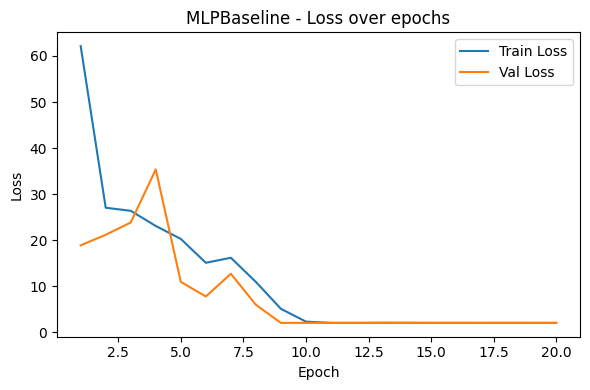

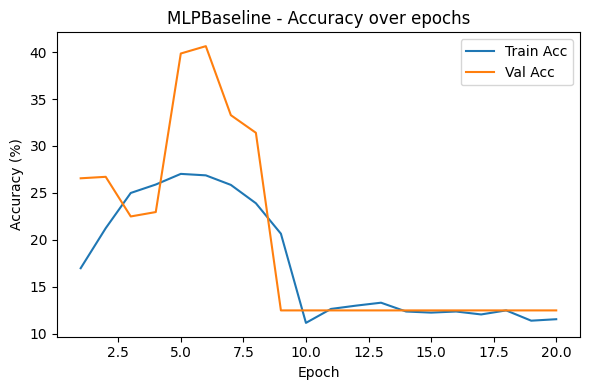


MLPBaseline classification report:
              precision    recall  f1-score   support

    basophil       0.52      0.31      0.39        80
  eosinophil       0.00      0.00      0.00        80
erythroblast       0.57      0.84      0.68        80
          ig       0.42      0.23      0.29        80
  lymphocyte       1.00      0.01      0.02        80
    monocyte       0.00      0.00      0.00        80
  neutrophil       0.22      0.96      0.35        80
    platelet       0.99      0.90      0.94        80

    accuracy                           0.41       640
   macro avg       0.46      0.41      0.34       640
weighted avg       0.46      0.41      0.34       640



<local>\miniconda3\envs\myenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
<local>\miniconda3\envs\myenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
<local>\miniconda3\envs\myenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [16]:
# Baseline 1: MLP
mlp_model = MLPBaseline(num_classes=num_classes)
mlp_model, hist_mlp = run_experiment(
    mlp_model,
    train_loader,
    val_loader,
    device,
    num_epochs=20,
    lr=1e-3,
    weight_decay=1e-4,
    model_name="MLPBaseline",
)
plot_history(hist_mlp, title_prefix="MLPBaseline")

if hist_mlp["val_labels"] is not None:
    print("\nMLPBaseline classification report:")
    print(classification_report(
        hist_mlp["val_labels"],
        hist_mlp["val_preds"],
        target_names=[id_to_class[i] for i in range(num_classes)]
    ))

SmallCNN | Epoch 1/25 | Train Loss: 2.0909, Train Acc: 15.43% | Val Loss: 1.8856, Val Acc: 22.50%
  -> New best SmallCNN with Val Acc: 22.50%
SmallCNN | Epoch 2/25 | Train Loss: 1.7402, Train Acc: 35.59% | Val Loss: 1.7650, Val Acc: 31.56%
  -> New best SmallCNN with Val Acc: 31.56%
SmallCNN | Epoch 3/25 | Train Loss: 1.6576, Train Acc: 38.71% | Val Loss: 1.5883, Val Acc: 41.88%
  -> New best SmallCNN with Val Acc: 41.88%
SmallCNN | Epoch 4/25 | Train Loss: 1.6003, Train Acc: 42.42% | Val Loss: 1.5814, Val Acc: 42.50%
  -> New best SmallCNN with Val Acc: 42.50%
SmallCNN | Epoch 5/25 | Train Loss: 1.5795, Train Acc: 46.60% | Val Loss: 1.6102, Val Acc: 40.00%
SmallCNN | Epoch 6/25 | Train Loss: 1.5634, Train Acc: 47.70% | Val Loss: 1.5532, Val Acc: 41.56%
SmallCNN | Epoch 7/25 | Train Loss: 1.5450, Train Acc: 47.03% | Val Loss: 1.5185, Val Acc: 42.81%
  -> New best SmallCNN with Val Acc: 42.81%
SmallCNN | Epoch 8/25 | Train Loss: 1.4925, Train Acc: 52.07% | Val Loss: 1.3802, Val Acc: 55.

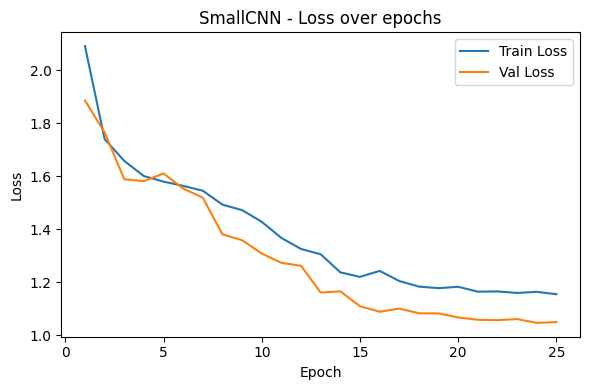

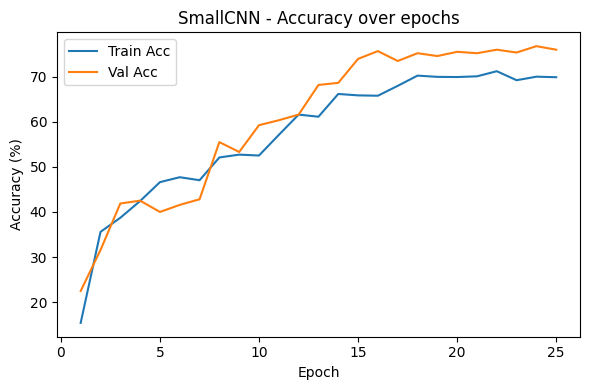


SmallCNN classification report:
              precision    recall  f1-score   support

    basophil       0.80      0.76      0.78        80
  eosinophil       0.88      0.81      0.84        80
erythroblast       0.82      0.64      0.72        80
          ig       0.63      0.47      0.54        80
  lymphocyte       0.57      0.93      0.70        80
    monocyte       0.83      0.65      0.73        80
  neutrophil       0.79      0.89      0.84        80
    platelet       0.93      0.99      0.96        80

    accuracy                           0.77       640
   macro avg       0.78      0.77      0.76       640
weighted avg       0.78      0.77      0.76       640



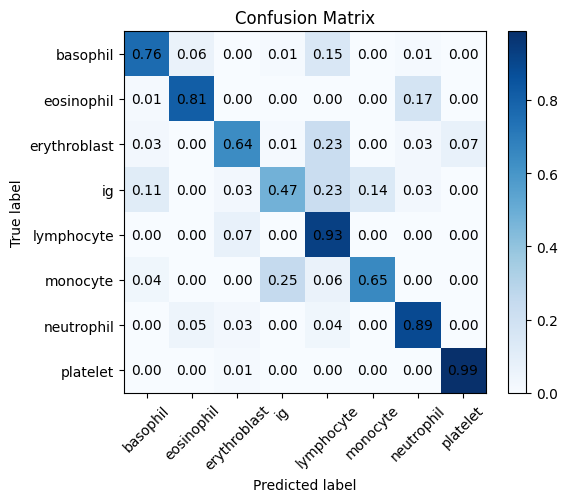

In [17]:
# Baseline 2: SmallCNN
small_cnn = SmallCNN(num_classes=num_classes)
small_cnn, hist_small = run_experiment(
    small_cnn,
    train_loader,
    val_loader,
    device,
    num_epochs=25,
    lr=1e-3,
    weight_decay=1e-4,
    model_name="SmallCNN",
)
plot_history(hist_small, title_prefix="SmallCNN")

if hist_small["val_labels"] is not None:
    print("\nSmallCNN classification report:")
    print(classification_report(
        hist_small["val_labels"],
        hist_small["val_preds"],
        target_names=[id_to_class[i] for i in range(num_classes)]
    ))
    plot_confusion_matrix(
        hist_small["val_labels"],
        hist_small["val_preds"],
        [id_to_class[i] for i in range(num_classes)],
        normalize=True,
    )

            DeepResCNN Model Architecture           
DeepResCNN(
  (stem): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): Mish()
  )
  (layers): Sequential(
    (0): ResidualBlock(
      (conv): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): Mish()
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (se): SEBlock(
        (avg_pool): AdaptiveAvgPool2d(output_size=1)
        (fc): Sequential(
          (0): Linear(in_features=64, out_features=4, bias=True)
          (1): ReLU()
          (2): Linear(in_features=4, out_features=64, bias=Tr

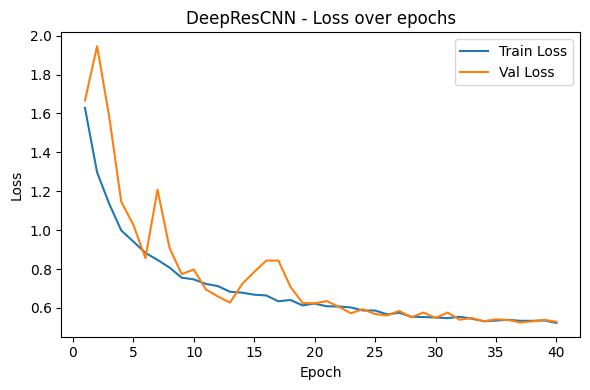

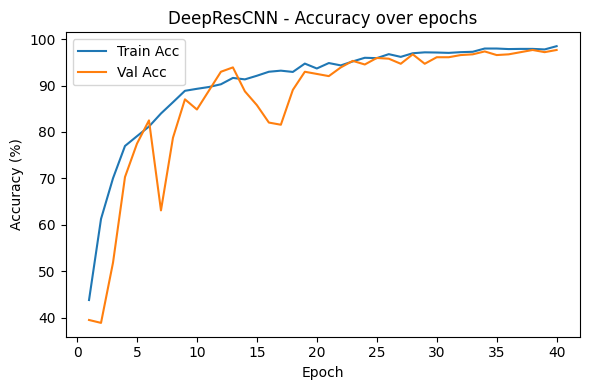


DeepResCNN classification report:
              precision    recall  f1-score   support

    basophil       0.99      0.97      0.98        80
  eosinophil       0.99      0.99      0.99        80
erythroblast       1.00      0.97      0.99        80
          ig       0.96      0.93      0.94        80
  lymphocyte       0.98      1.00      0.99        80
    monocyte       0.97      0.95      0.96        80
  neutrophil       0.94      1.00      0.97        80
    platelet       0.99      1.00      0.99        80

    accuracy                           0.98       640
   macro avg       0.98      0.98      0.98       640
weighted avg       0.98      0.98      0.98       640



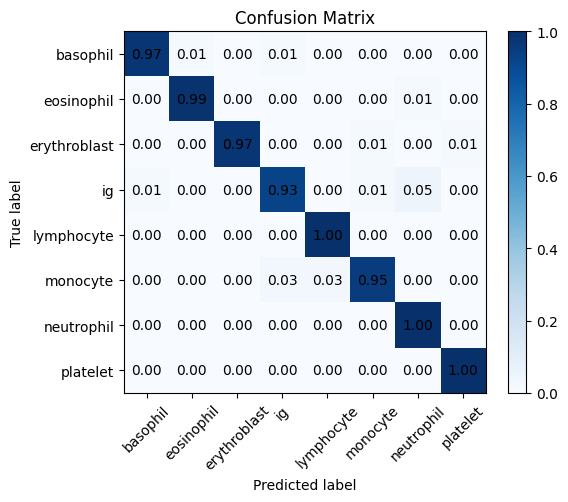

In [20]:
# Main model: DeepResCNN

deep_model = DeepResCNN(num_classes=num_classes)
deep_model = deep_model.to(device)

# ---- PRINT ARCHITECTURE (SAFE, NO EXTRA LIBRARIES) ----
print("====================================================")
print("            DeepResCNN Model Architecture           ")
print("====================================================")
print(deep_model)   # prints full architecture

# Count parameters
def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("\nTotal Trainable Parameters:", count_trainable_params(deep_model))
print("====================================================\n")

# ---- TRAIN MODEL ----
deep_model, hist_deep = run_experiment(
    deep_model,
    train_loader,
    val_loader,
    device,
    num_epochs=40,
    lr=1e-3,
    weight_decay=1e-4,
    model_name="DeepResCNN",
)

plot_history(hist_deep, title_prefix="DeepResCNN")

# ---- VALIDATION RESULTS ----
if hist_deep["val_labels"] is not None:
    print("\nDeepResCNN classification report:")
    print(classification_report(
        hist_deep["val_labels"],
        hist_deep["val_preds"],
        target_names=[id_to_class[i] for i in range(num_classes)]
    ))

    plot_confusion_matrix(
        hist_deep["val_labels"],
        hist_deep["val_preds"],
        [id_to_class[i] for i in range(num_classes)],
        normalize=True,
    )


In [ ]:
#---- PREDICTIONS ON TEST SET ----
deep_model = deep_model.to(device)
deep_model.eval()

predictions = {}

with torch.no_grad():
    for imgs, filenames in test_loader:
        imgs = imgs.to(device)
        outputs = deep_model(imgs)
        preds = outputs.argmax(dim=1).cpu().numpy()
        for fname, p in zip(filenames, preds):
            predictions[fname] = int(p)

output_filename = "prediction_labels.json"
with open(output_filename, "w") as f:
    json.dump(predictions, f, indent=4)

print(f"Saved {len(predictions)} predictions to {output_filename}")

Saved 1000 predictions to prediction_labels.json
